# Analyse Improvement from Loop1 to Loop2.

## Prepare Notebook.

### Autoreload Environment.

In [1]:
%reload_ext autoreload
%autoreload 2

### Import Libraries.

In [2]:
import math
import sys
import os
import yaml

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as stats
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


### Import Additional Modules.

In [3]:
sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import get_forward_model


### Read Annotation Configurations.

In [4]:
config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config_path, "r") as fb:
    annot_dict = yaml.safe_load(fb)
protocol_cols = annot_dict["protocol_columns"]

### Read Constraints Configurations.

In [5]:
constraints_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]


## Load Data.

### Load Annotated Data without LPHO012 Experiment.

In [6]:
path_adata_old = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_old_experiments_.h5ad"
adata_old = sc.read_h5ad(path_adata_old)
adata_old

AnnData object with n_obs × n_vars = 449218 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Annotated Data with LPHO012 Experiment.


In [7]:
path_adata_new = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
adata_new = sc.read_h5ad(path_adata_new)
adata_new

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

### Load Full Adata without LPHO012.


In [8]:
path_adata_full_old = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_old_experiments_.h5ad"
adata_full_old = sc.read_h5ad(path_adata_full_old)
adata_full_old

AnnData object with n_obs × n_vars = 48189887 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Load Full Adata with LPHO012.


In [9]:
path_adata_full = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad"
adata_full = sc.read_h5ad(path_adata_full)
adata_full

AnnData object with n_obs × n_vars = 52085765 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Prepare Unique Real Conditions.


In [10]:
# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_conds = adata_full.obs[protocol_cols].astype(float).values   # or use obs[protocol_columns].values
exp_nums = adata_full.obs["experiment_number"].values

# Get unique condition per experiment
unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]   # all cells in same exp share the same condition
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
exp_labels = np.array(exp_labels)


### Fit Label Encoder.

In [11]:
ct_le = LabelEncoder().fit(adata_new.obs["cell_type"].values)
classes = ct_le.classes_
classes

array(['CD14Mono', 'CD16Mono', 'CyclingPro1', 'CyclingPro2', 'Early_GMP',
       'EosBasMast1', 'EosBasMast2', 'EosBasMast3', 'EryPro',
       'GMP-Neutro', 'GMP_cycling', 'HSCs', 'LMPP-CLP', 'MLP', 'MPP',
       'MPP_MgkEry', 'MgKEryPro1', 'MgKEryPro2', 'ProB', 'earlyMPP',
       'late_MgkPro', 'preProB', 'pre_cDC1', 'pre_cDC2'], dtype=object)

## Read Solutions from Loop0.

### Read Candidates Data.

In [13]:

candidates_base_dir = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official"
opt_modes_list = os.listdir(candidates_base_dir)

# Define uncertainty columns
ct_prop_std_cols = [f"{ct}_prop_std" for ct in classes]   # ensure 'classes' is defined
other_scores_cols = [
    "exploration_score", "exploitation_score", "metric_response_surface",
    "indices", "losses", "acq_values", "late_MgkPro_prop",
    "target_ct_loss_mean", "target_ct_loss_std", "ct_prop_total_variance"
]
uq_annot_cols = ct_prop_std_cols + other_scores_cols      # FIXED variable name
uq_loop0_annot_cols = [f"loop0:{col}" for col in uq_annot_cols]
uq_loop1_annot_cols = [f"loop1:{col}" for col in uq_annot_cols]

all_records = []
for opt_mode in opt_modes_list:
    opt_mode_base_dir = os.path.join(candidates_base_dir, opt_mode, "late_MgkPro")
    if not os.path.isdir(opt_mode_base_dir):
        continue
    runs_list = os.listdir(opt_mode_base_dir)
    for run_id in runs_list:
        run_dir = os.path.join(opt_mode_base_dir, run_id, "uncertainty_annotation")
        csv_loop0 = os.path.join(run_dir, "candidates_with_uncertainties.csv")
        csv_loop1 = os.path.join(run_dir, "candidates_with_uncertainties_next_loop.csv")
        
        if not (os.path.exists(csv_loop0) and os.path.exists(csv_loop1)):
            print(f"Missing files for {opt_mode}/{run_id}, skipping")
            continue
        
        df0 = pd.read_csv(csv_loop0)
        df1 = pd.read_csv(csv_loop1)
        
        # Add metadata
        df0["run"] = run_id
        df0["opt_mode"] = opt_mode
        df1["run"] = run_id
        df1["opt_mode"] = opt_mode
        
        # Rename annotation columns to indicate loop origin
        df0_annot = df0[uq_annot_cols].rename(columns=dict(zip(uq_annot_cols, uq_loop0_annot_cols)))
        df1_annot = df1[uq_annot_cols].rename(columns=dict(zip(uq_annot_cols, uq_loop1_annot_cols)))
        
        # Merge annotations with the original candidate data (assuming same row order)
        # Use concat along columns; reset index to avoid misalignment
        df0_with_both = pd.concat([df0, 
                                   df0_annot, 
                                   df1_annot], axis=1)
        all_records.append(df0_with_both)

candidates_df = pd.concat(all_records, ignore_index=True)


### Filter Out Infeasible Candidates.

In [14]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
# define mask for all columns
marker_mask = np.full(candidates_df.shape[0], True)

# ----  Protocol Columns Loop ----
for col in protocol_cols:
    # get col bounds
    col_ubound = ubound_dict[col]
    col_lbound = lbound_dict[col]
    print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

    # get col values and mask
    col_values = candidates_df[col]
    col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
    col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

    # get masks for current column
    old_mask = marker_mask
    lbound_marker_mask = marker_mask & col_mask_lbound_mask
    ubound_marker_mask = marker_mask & col_mask_ubound_mask
    marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

    # get number of solutions
    n_previously_accepted_solutions = old_mask.sum()
    n_accepted_solutions = marker_mask.sum()
    n_solutions_passing_ubound = col_mask_ubound_mask.sum()
    n_solutions_passing_lbound = col_mask_lbound_mask.sum()
    n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
    n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
    print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
    print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
    print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


    # write values for constraint on current column
    candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
    candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

# write values for all constraints
n_all_solutions = candidates_df.shape[0]
n_accepted_solutions = marker_mask.sum()
candidates_df["passes_constraints:all"] = marker_mask

print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 37200 ---
			 --- Number Currently Accepted Solutions 34785 ---
			 --- Number of Solution Satisfying Upper Bound 34785 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 34785 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 37200 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 34785 ---
			 --- Number Currently Accepted Solutions 30333 ---
			 --- Number of Solution Satisfying Upper Bound 31757 ---
			 --- Number of Solution Satisfying Lower Bound 37200 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 30333 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 34785 ---
		---- Processing Column sr1_[nm] -> U: 750.0, L: 

### Filter Candidates for MgkPro Enrichment.

In [30]:
# ---- Define target cell type ----
target_ct = "late_MgkPro"
target_ct_prop_col = f"{target_ct}_prop"

# ---- Define filtering mask ----
filtering_col = "passes_constraints:all"
target_ct_col = "cfg:sampling:target_cell_type"
min_ct_prop = 0.05
# min_ct_prop = 0.00
passes_constraints_mask = candidates_df[filtering_col]
is_target_ct_mask = candidates_df[target_ct_col] == target_ct
is_enriched_mask = candidates_df[target_ct_prop_col] > min_ct_prop
mask = passes_constraints_mask & is_target_ct_mask & is_enriched_mask

# ---- Filter data and get concentrations ---
filtered_candidates_df = candidates_df[mask]
filtered_concs_orig = filtered_candidates_df[protocol_cols].astype(float)
filtered_concs = pd.DataFrame(np.log1p(filtered_concs_orig.values), columns=filtered_concs_orig.columns, index=filtered_concs_orig.index)
filtered_concs


,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
6,1.262443,0.151013,2.853473,5.153642,0.000000,0.016714,4.647359,0.000000,0.0,0.002008,3.055289,2.697248
31,1.106483,0.129971,2.072724,5.018177,0.030996,0.058780,4.510143,0.000000,0.0,0.000000,3.077012,2.689068
39,0.540911,0.031571,0.592296,4.656776,0.085340,0.000000,4.675730,0.031524,0.0,0.000000,2.908877,2.761823
189,0.513740,0.038895,0.767906,4.614037,0.091505,0.000000,4.674728,0.034228,0.0,0.000000,2.904467,2.761530
239,0.515126,0.038760,0.763537,4.614436,0.091011,0.000000,4.674562,0.034209,0.0,0.000000,2.904345,2.761862
...,...,...,...,...,...,...,...,...,...,...,...,...
36981,1.001307,0.238753,1.464355,5.004721,0.000000,0.063724,4.575740,0.000000,0.0,0.000000,3.061900,2.692795
37031,0.957709,0.259773,1.162176,4.949767,0.000000,0.069791,4.594295,0.000000,0.0,0.000000,3.065074,2.716994
37050,2.408237,1.197051,0.081108,3.795048,0.000000,0.106740,0.595418,0.000000,0.0,0.129280,3.030583,2.479722
37131,1.502598,1.168685,1.487798,3.135093,0.369971,0.008569,0.449446,0.000000,0.0,0.018054,3.057357,2.511979


In [31]:
filtered_candidates_df["loop1:late_MgkPro_prop"]


6        0.071663
31       0.095686
39       0.057597
189      0.061686
239      0.061605
           ...   
36981    0.133131
37031    0.139908
37050    0.059552
37131    0.061071
37150    0.056277
Name: loop1:late_MgkPro_prop, Length: 692, dtype: float64

In [32]:
filtered_candidates_df["loop0:late_MgkPro_prop"]

6        0.071663
31       0.095686
39       0.057597
189      0.061686
239      0.061605
           ...   
36981    0.133131
37031    0.139908
37050    0.059552
37131    0.061071
37150    0.056277
Name: loop0:late_MgkPro_prop, Length: 692, dtype: float64

### Define plot df.

In [33]:
# ---- Define mapping for column names ----
col_map ={
    "loop0:target_ct_loss_std": "Uncertainty Before",
    "loop1:target_ct_loss_std": "Uncertainty After",
    "loop0:target_ct_loss_mean": "Performance Before",
    "loop1:target_ct_loss_mean": "Performance After",
    "loop0:late_MgkPro_prop": "% of MgkPro",
}

# ----- Defining dataframe to plot ----
plot_df = pd.DataFrame(
    {
        col_map[col]: filtered_candidates_df[col] for col in col_map.keys()
    },
    index=filtered_candidates_df.index
)
plot_df["Delta Uncertainty"] = plot_df["Uncertainty Before"] - plot_df["Uncertainty After"]
plot_df["Delta Performance"] = plot_df["Performance Before"] - plot_df["Performance After"]

# ---- Write columns to original data frame ----
filtered_candidates_df["Delta Uncertainty"] = plot_df["Delta Uncertainty"]
filtered_candidates_df["Uncertainty Before"] = plot_df["Uncertainty Before"]
filtered_candidates_df["Uncertainty After"] = plot_df["Uncertainty After"]

filtered_candidates_df["Delta Performance"] = plot_df["Delta Performance"]
filtered_candidates_df["Performance Before"] = plot_df["Performance Before"]
filtered_candidates_df["Performance After"] = plot_df["Performance After"]

filtered_candidates_df["% of MgkPro"] = plot_df["% of MgkPro"]

plot_df

/tmp/ipykernel_656986/944871988.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_df["Delta Uncertainty"] = plot_df["Delta Uncertainty"]
/tmp/ipykernel_656986/944871988.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_df["Uncertainty Before"] = plot_df["Uncertainty Before"]
/tmp/ipykernel_656986/944871988.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

,Uncertainty Before,Uncertainty After,Performance Before,Performance After,% of MgkPro,Delta Uncertainty,Delta Performance
6,0.338706,9.767701e-02,8.843169,0.113225,0.071663,0.241029,8.729944
31,0.414317,9.530506e-03,7.529451,0.011238,0.095686,0.404786,7.518213
39,0.377195,7.443549e-07,6.815532,0.000001,0.057597,0.377194,6.815531
189,0.618461,4.614881e-06,6.713004,0.000003,0.061686,0.618456,6.713000
239,0.358764,3.401126e-06,6.458906,0.000003,0.061605,0.358760,6.458903
...,...,...,...,...,...,...,...
36981,0.403278,7.759372e-04,7.195938,0.000872,0.133131,0.402502,7.195065
37031,0.544114,2.887817e-04,6.395267,0.000293,0.139908,0.543826,6.394974
37050,0.460056,3.747077e-01,8.786738,9.615453,0.059552,0.085348,-0.828715
37131,0.396592,4.798002e-01,8.404979,6.207895,0.061071,-0.083208,2.197084


### Plot Improvement against uncertainty.

/tmp/ipykernel_656986/1705227913.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


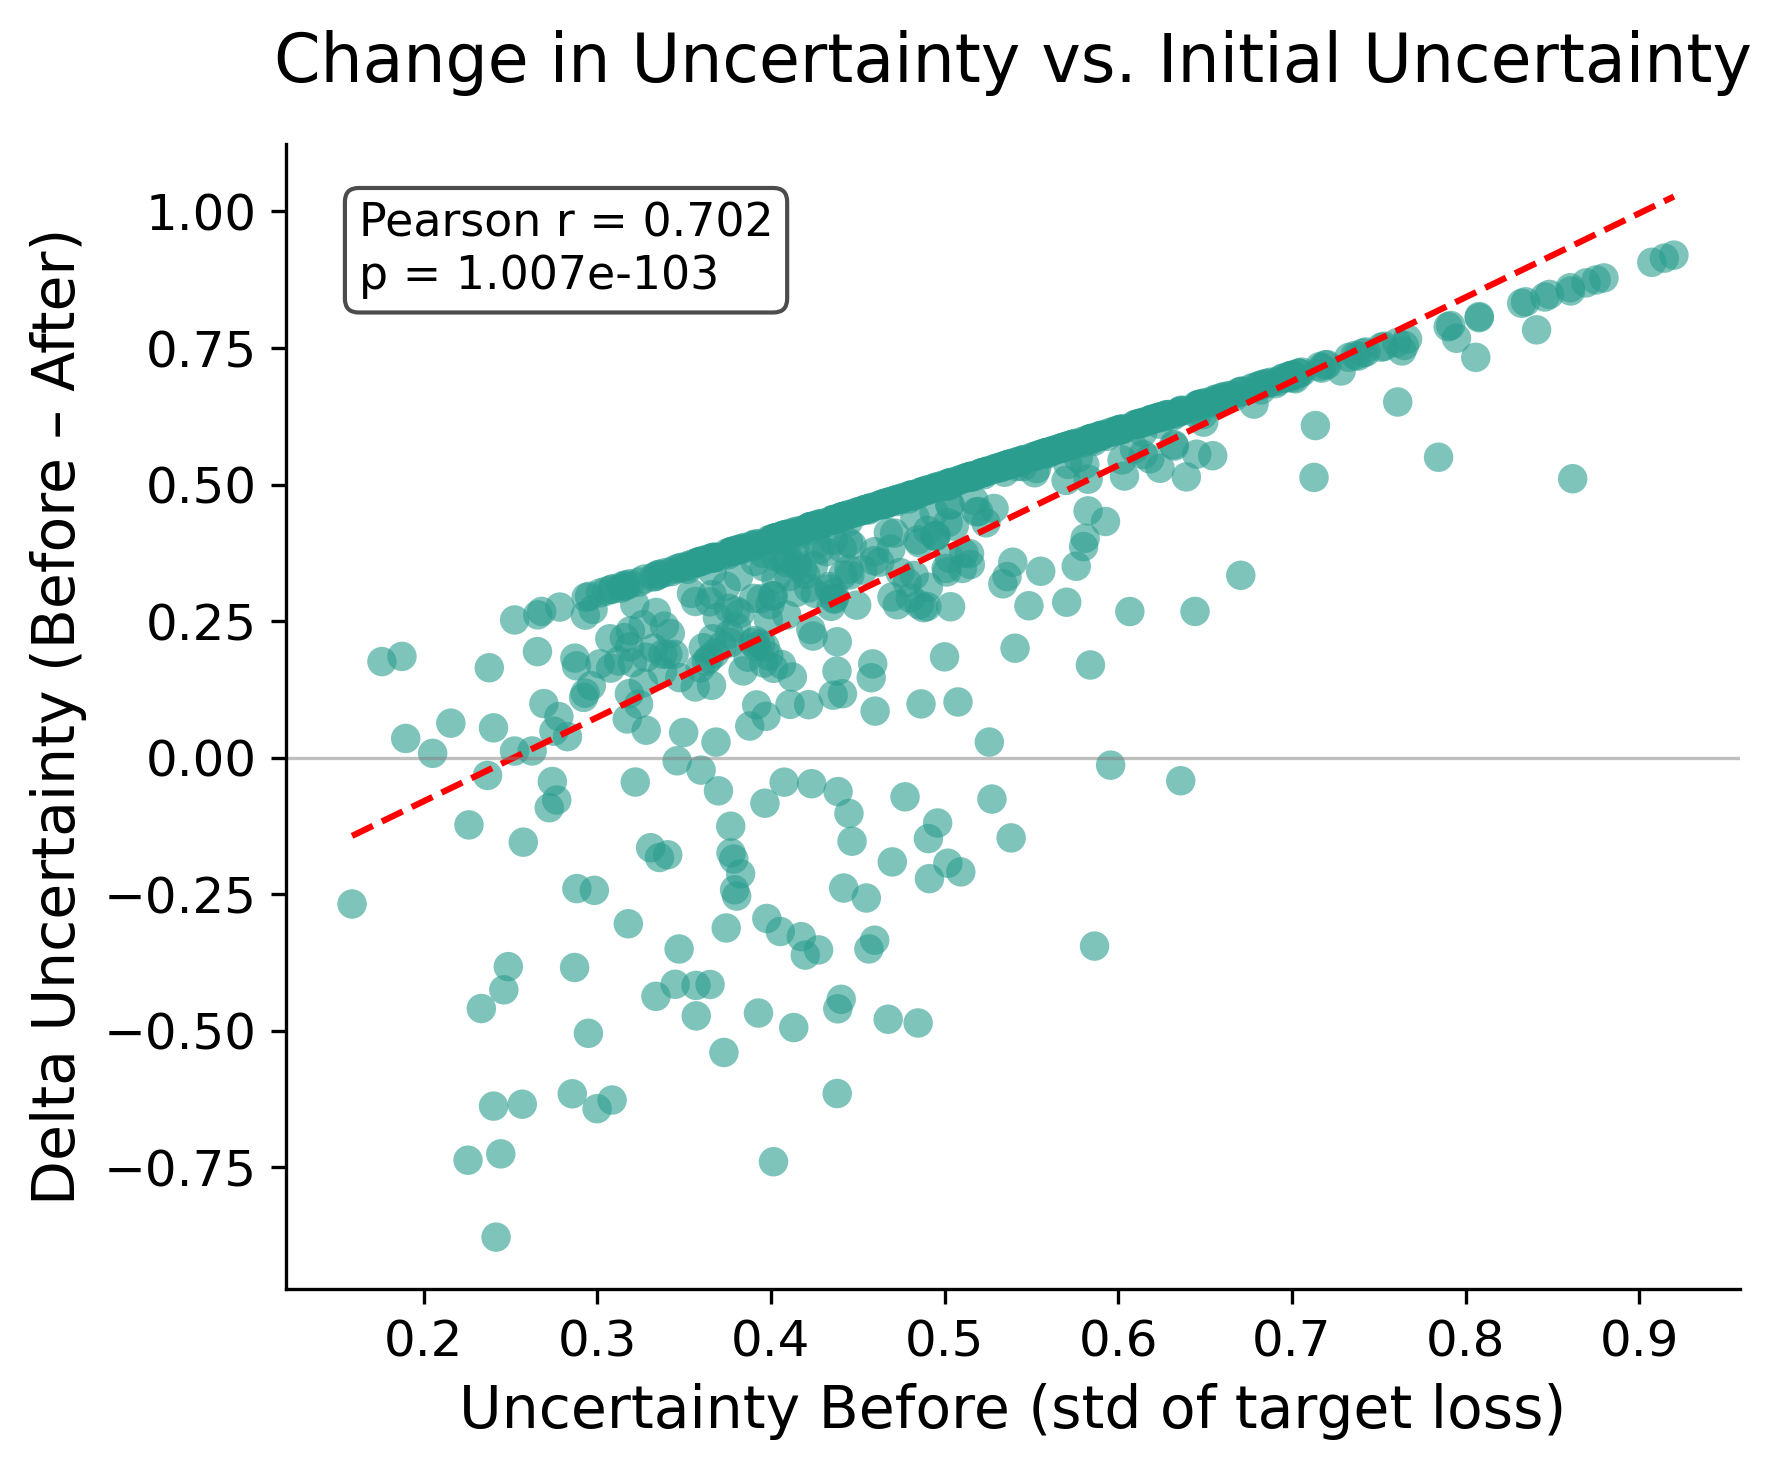

/tmp/ipykernel_656986/1705227913.py:53: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_main, alpha=0.6, label='Candidates', edgecolor='none')


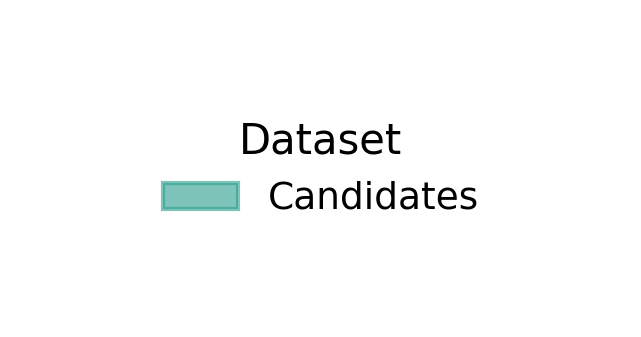

In [34]:
# Prepare data (ensure no NaN)
plot_df_clean = plot_df.dropna(subset=["Uncertainty Before", "Delta Uncertainty"])

# Compute correlation
corr, p_val = stats.pearsonr(plot_df_clean["Uncertainty Before"], plot_df_clean["Delta Uncertainty"])

# ------------------------------------------------------------
# 1. Main scatter plot (smaller figure, larger text)
# ------------------------------------------------------------
plt.figure(figsize=(6, 5), dpi=300)          # reduced from (8,6) to (6,5)

# Use first color from palette
color_main = "#2a9d8f"

plt.scatter(plot_df_clean["Uncertainty Before"], plot_df_clean["Delta Uncertainty"],
            c=color_main, alpha=0.6, s=50, edgecolor='none')

# Add regression line
z = np.polyfit(plot_df_clean["Uncertainty Before"], plot_df_clean["Delta Uncertainty"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(plot_df_clean["Uncertainty Before"].min(), plot_df_clean["Uncertainty Before"].max(), 100)
plt.plot(x_line, p_line(x_line), color='red', linestyle='--', linewidth=1.5, label='_nolegend_')

# Add correlation annotation (slightly smaller font to fit)
plt.text(0.05, 0.95, f'Pearson r = {corr:.3f}\np = {p_val:.3e}',
         transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Labels and title with larger fonts
plt.xlabel("Uncertainty Before (std of target loss)", fontsize=14)   # increased from 12 to 14
plt.ylabel("Delta Uncertainty (Before – After)", fontsize=14)        # increased from 12 to 14
plt.title("Change in Uncertainty vs. Initial Uncertainty", fontsize=16, pad=15)  # increased from 14 to 16

# Increase tick label size
plt.tick_params(axis='both', labelsize=12)

# Horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

# Remove any potential legend
plt.legend().remove()
sns.despine()
plt.tight_layout()

# Save main plot
plt.savefig('output/scatter_uncertainty_delta_vs_before.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Save the legend separately (single color patch)
# ------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=color_main, alpha=0.6, label='Candidates', edgecolor='none')
]

fig_legend = plt.figure(figsize=(2.5, 1.2), dpi=300)   # slightly smaller legend as well
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                 fontsize=9, loc='center', frameon=False)
fig_legend.savefig('output/scatter_uncertainty_legend_separate.png', bbox_inches='tight', dpi=300)
plt.show()


/tmp/ipykernel_656986/3735328594.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = plt.legend()


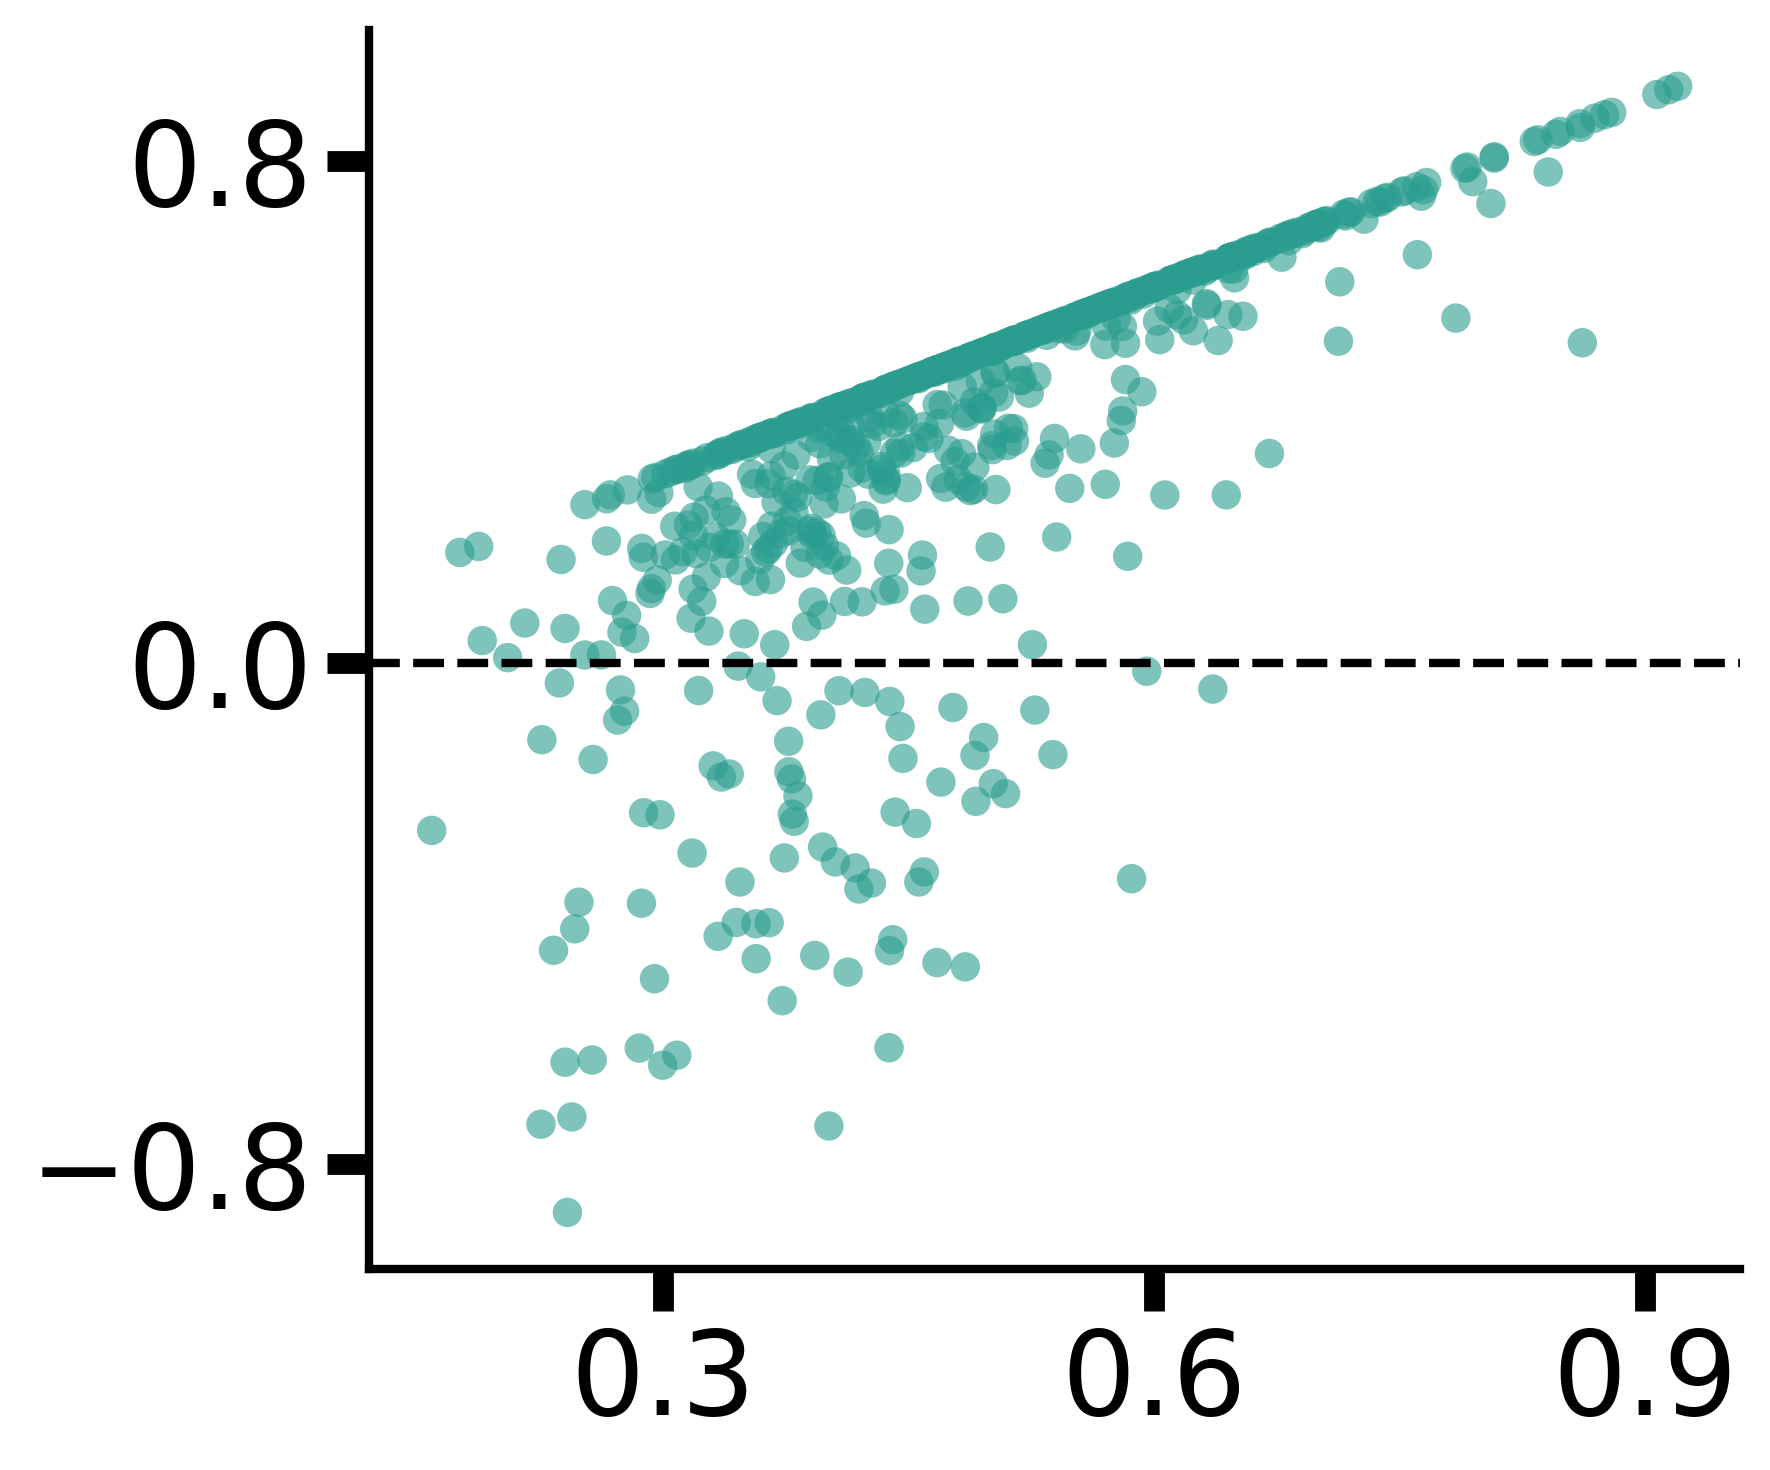

/tmp/ipykernel_656986/3735328594.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=color_main, alpha=0.6, label='Candidates', edgecolor='none')


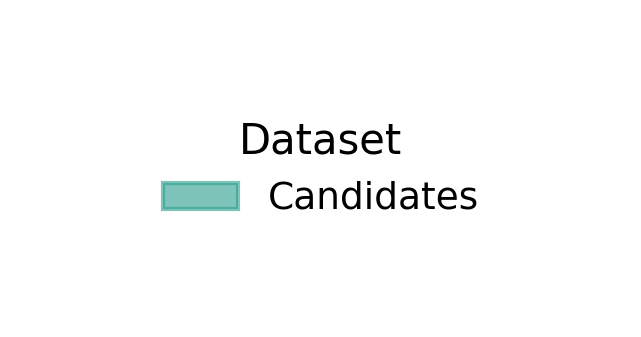

In [40]:
import matplotlib.ticker as ticker

# ... (palette, data prep, correlation as before)

# ------------------------------------------------------------
# 1. Stylized scatter plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5), dpi=300)


# Bigger dots (s=90 instead of 50)
plt.scatter(plot_df_clean["Uncertainty Before"], plot_df_clean["Delta Uncertainty"],
            c=color_main, alpha=0.6, s=50, edgecolor='none')

# ---------------- AXIS & TICK STYLING ----------------
ax = plt.gca()

# 1. Make the spines (axes) thicker
for spine in ax.spines.values():
    spine.set_linewidth(2)          # thick axis lines

# 2. Fewer ticks: ~4 on x, ~5 on y (sparser)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))

# 3. Big, bold tick marks
ax.tick_params(axis='both', which='major',
               labelsize=20,        # bigger numbers
               length=8,           # longer ticks
               width=2,            # thicker ticks
               color='black')      # dark tick lines

ax.tick_params(axis='both', which='major',
labelsize=28,        # larger numbers (e.g., 24, 28, 32)
length=10,           # longer ticks
width=5,           # slightly thicker ticks
color='black')
# ------------------------------------------------------


# Horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--', linewidth=2.0, alpha=1.0)

# Remove legend entirely (already absent, but make sure)
legend = plt.legend()
if legend:
    legend.remove()

# Despine only top/right; keep bottom/left thick
sns.despine()

plt.tight_layout()
plt.savefig('output/scatter_uncertainty_delta_vs_before_styled.png', bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------
# 2. Separate legend (optional) – unchanged from original
# ------------------------------------------------------------
legend_handles = [
    mpatches.Patch(color=color_main, alpha=0.6, label='Candidates', edgecolor='none')
]
fig_legend = plt.figure(figsize=(2.5, 1.2), dpi=300)
ax_legend = fig_legend.add_subplot(111)
ax_legend.axis('off')
ax_legend.legend(handles=legend_handles, title='Dataset', title_fontsize=10,
                 fontsize=9, loc='center', frameon=False)
fig_legend.savefig('output/scatter_uncertainty_legend_separate.png', bbox_inches='tight', dpi=300)
plt.show()

### Visualize Comparison Before After MEM.

In [33]:
for c in candidates_df.columns:print(c)

Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:bas

In [32]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import seaborn as sns

# =============================================================================
# Configuration
# =============================================================================
# Your dataframes (replace with actual paths or variable names)
# candidates_df = ...  # original candidates
# protocol_cols = ...  # list of concentration columns (e.g., ['col1', 'col2'])

threshold = 0.15                # MgkPro enrichment threshold
bins = 5
color_before = "#2a9d8f"      # old / before
color_after  = "#e76f51"       # new / after

# -----------------------------------------------------------------------------
# 1. Apply initial constraint filter to both "before" and "after"
# -----------------------------------------------------------------------------
mask_constraints = candidates_df["passes_constraints:all"]

# Before = only constraints
# df_before = candidates_df[mask_constraints].copy()
df_before = filtered_candidates_df.copy()

# After = constraints + enrichment on late_MgkPro_prop
# mask_enrich = df_before["late_MgkPro_prop"] > threshold
# df_before = filtered_candidates_df.copy()

print(f"Before enrichment: {len(df_before)} candidates")
# print(f"After enrichment:  {len(df_after)} candidates")

# =============================================================================
# 2. Loop over annotation columns and create plots
# =============================================================================
annot_cols = ["target_ct_loss_mean", f"target_ct_loss_std", "late_MgkPro_prop"]
annot_cols = ["late_MgkPro_prop"]
for col in annot_cols:
    # Drop missing values (if any)
    col_before = f"loop0:{col}"
    col_after = f"loop1:{col}"
    data_before = df_before[col_before].dropna()
    data_after  = df_before[col_after].dropna()

    # Skip if no data or constant column
    if len(data_before) == 0 or len(data_after) == 0:
        print(f"Skipping {col}: no data in one of the groups")
        continue
    if data_before.std() == 0 and data_after.std() == 0:
        print(f"Skipping {col}: constant column")
        continue

    # Histograms (density)
    hist_before, edges_before = np.histogram(data_before, bins=bins, density=True)
    hist_after,  edges_after  = np.histogram(data_after,  bins=bins, density=True)

    centers_before = (edges_before[:-1] + edges_before[1:]) / 2
    centers_after  = (edges_after[:-1]  + edges_after[1:])  / 2
    width_before = np.diff(edges_before)[0]
    width_after  = np.diff(edges_after)[0]

    # KDE
    kde_before = stats.gaussian_kde(data_before)
    kde_after  = stats.gaussian_kde(data_after)

    x_min = min(data_before.min(), data_after.min())
    x_max = max(data_before.max(), data_after.max())
    x_grid = np.linspace(x_min, x_max, 200)

    # -------------------------------------------------------------------------
    # Main plot
    # -------------------------------------------------------------------------
    plt.figure(figsize=(3, 3), dpi=300)

    # Bars
    plt.bar(centers_before, hist_before, width=width_before,
            color=color_before, alpha=0.5, edgecolor='black', linewidth=0.8,
            label='before enrichment', align='center')
    plt.bar(centers_after, hist_after, width=width_after,
            color=color_after, alpha=0.5, edgecolor='black', linewidth=0.8,
            label='after enrichment', align='center')

    # KDE lines
    plt.plot(x_grid, kde_before(x_grid), color=color_before, linewidth=2, label='_nolegend_')
    plt.plot(x_grid, kde_after(x_grid),  color=color_after,  linewidth=2, label='_nolegend_')
    # Filled KDE
    plt.fill_between(x_grid, kde_before(x_grid), color=color_before, alpha=0.2)
    plt.fill_between(x_grid, kde_after(x_grid),  color=color_after,  alpha=0.2)

    # Labels & appearance
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.yscale('symlog')                    # symmetric log scale (handles zeros)
    plt.title(f'Distribution of {col}', fontsize=14, pad=15)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f'output/annotation_{col}_before_after.png', bbox_inches='tight', dpi=300)
    plt.show()

    # -------------------------------------------------------------------------
    # Separate legend (circles/dots)
    # -------------------------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color_before,
               markeredgecolor='black', markersize=8, label='before enrichment', alpha=0.5),
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color_after,
               markeredgecolor='black', markersize=8, label='after enrichment', alpha=0.5)
    ]

    fig_legend = plt.figure(figsize=(2.5, 1.2), dpi=300)
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')
    ax_legend.legend(handles=legend_handles, title='Filtering', title_fontsize=10,
                     fontsize=8, loc='center', frameon=False)
    fig_legend.savefig(f'output/legend_{col}.png', bbox_inches='tight', dpi=300)
    plt.show()

Before enrichment: 21952 candidates


KeyError: 'loop0:late_MgkPro_prop'

### Scatter plot Before After.

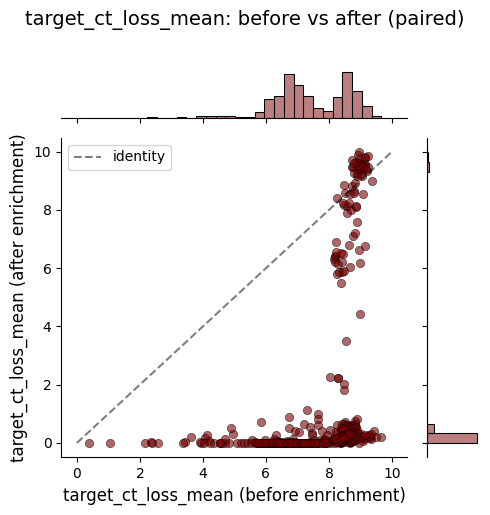

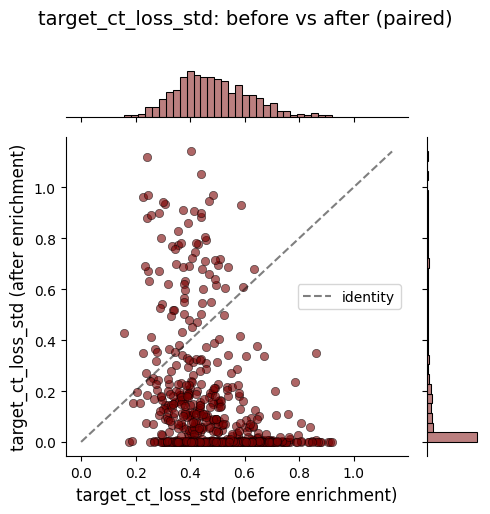

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure index column exists
if 'index' not in df_before.columns:
    df_before = df_before.reset_index(drop=False)

# **CRITICAL: Remove duplicate column names**
df_before = df_before.loc[:, ~df_before.columns.duplicated(keep='first')]

cols_to_plot = ["target_ct_loss_mean", "target_ct_loss_std"]
palette = '#780000'

for col in cols_to_plot:
    col_before = f"loop0:{col}"
    col_after  = f"loop1:{col}"
    
    # Create jointplot directly from df_before
    g = sns.jointplot(
        data=filtered_candidates_df,
        x=col_before,
        y=col_after,
        kind='scatter',
        color=palette,
        alpha=0.6,
        edgecolor='black',
        linewidth=0.5,
        height=5,
        space=0.2,
        marginal_kws=dict(bins=30, fill=True, alpha=0.5)
    )
    
    # Identity line (y = x)
    min_val = min(df_before[col_before].min(), df_before[col_after].min())
    max_val = max(df_before[col_before].max(), df_before[col_after].max())
    g.ax_joint.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='identity')
    
    # g.ax_joint.set_xscale('log')
    # g.ax_joint.set_yscale('log')

    g.set_axis_labels(f'{col} (before enrichment)', f'{col} (after enrichment)', fontsize=12)
    g.fig.suptitle(f'{col}: before vs after (paired)', y=1.02, fontsize=14)
    g.ax_joint.legend()
    
    plt.tight_layout()
    plt.show()

## Analyse Covariance.

### Between Loss Mean.

In [23]:
col = "target_ct_loss_mean"
col_before = f"loop0:{col}"
col_after  = f"loop1:{col}"

x = filtered_candidates_df[col_before]
y = filtered_candidates_df[col_after]
diff = y - x

corr_y = np.corrcoef(diff, y)
print(f"{corr_y}")

corr_x = np.corrcoef(diff, x)
print(f"{corr_x}")


[[1.         0.87451449]
 [0.87451449 1.        ]]
[[ 1.         -0.07633178]
 [-0.07633178  1.        ]]


### Betweeen Loss Uncertainty and reduction.

In [24]:
col = "target_ct_loss_std"
col_before = f"loop0:{col}"
col_after  = f"loop1:{col}"

x = filtered_candidates_df[col_before]
y = filtered_candidates_df[col_after]
diff = y - x

corr_y = np.corrcoef(diff, y)
print(f"{corr_y}")

corr_x = np.corrcoef(diff, x)
print(f"{corr_x}")


[[1.         0.90210168]
 [0.90210168 1.        ]]
[[ 1.         -0.70180226]
 [-0.70180226  1.        ]]


## PCA analysis.

### Fit transformation.

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# real_matrix: (n_experiments, n_protocols) – binary condition vectors
# Standardize (recommended when variables have different units, though here all are 0/1)

real_matrix_log1p = np.log1p(real_matrix)
scale_data = False
if scale_data:
    scaler = StandardScaler()
    real_scaled = scaler.fit_transform(real_matrix_log1p)
else:
    real_scaled = real_matrix_log1p

pca = PCA(n_components=2)  # keep first two PCs for visualization
real_pca = pca.fit_transform(real_scaled)
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Optionally, view loadings
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=protocol_cols)
print(loadings)

Explained variance: [0.54803061 0.21678673]
                         PC1       PC2
gm-csf_[ng_ml]      0.107143 -0.157328
tpo_[ng_ml]         0.087001 -0.137288
sr1_[nm]            0.391690 -0.493256
um171_[nm]          0.781987  0.598133
um729_[µm]         -0.092241 -0.082130
scf_[ng_ml]         0.346346 -0.313072
butyzamide_[nm]    -0.287119  0.499589
retinoic_acid_[µm]  0.011053 -0.002077
ldl_[ng_ml]         0.050874 -0.010243
il3_[ng_ml]         0.045392 -0.008968
o2_[%]             -0.009418  0.002252
days_of_culture     0.016289 -0.028143


### Apply transformation.

In [23]:
# filtered_concs is already log1p-transformed (shape: n_candidates × n_protocols)
# Use the same scaler and PCA transform
if scale_data:
    filtered_scaled = scaler.transform(filtered_concs)
    filtered_pca = pca.transform(filtered_scaled)
else:
    filtered_pca = pca.transform(filtered_concs)

# Add PCA coordinates to the filtered DataFrame
filtered_candidates_df['PC1'] = filtered_pca[:, 0]
filtered_candidates_df['PC2'] = filtered_pca[:, 1]

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/tmp/ipykernel_656986/2336211449.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_candidates_df['PC1'] = filtered_pca[:, 0]
/tmp/ipykernel_656986/2336211449.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  filtered_candidates_df['PC2'] = filtered_pca[:, 1]
/tmp/ipykernel_656

### Flag target experiment.

In [24]:
# Find index of experiment 210
idx_210 = np.where(exp_labels == 210)[0]
if len(idx_210) > 0:
    exp210_pc1 = real_pca[idx_210[0], 0]
    exp210_pc2 = real_pca[idx_210[0], 1]
else:
    exp210_pc1 = exp210_pc2 = None
    print("Experiment 210 not found in real conditions.")

### Plot.

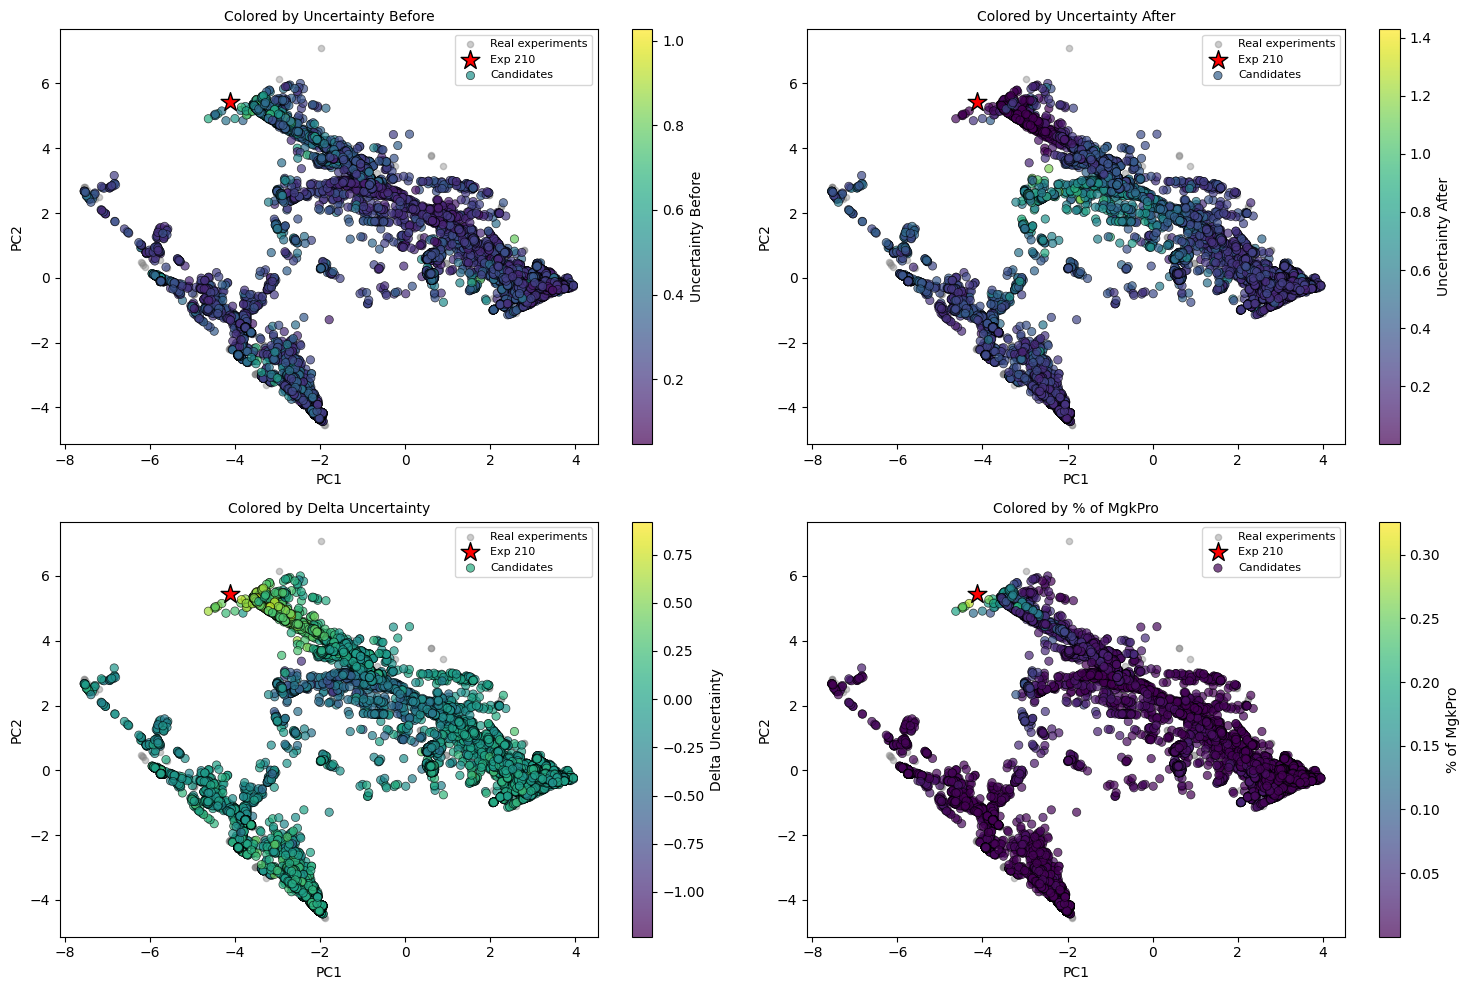

In [27]:
# After creating the subplots and before the loop over color columns,
# we can plot the gray points and star on each axes.

# color_cols = ["loop0:target_ct_loss_std", "loop1:target_ct_loss_std"]
color_cols = ["Uncertainty Before", "Uncertainty After", "Delta Uncertainty", "% of MgkPro"]
fig, axes = plt.subplots(2, (len(color_cols)+1)//2, figsize=(15, 10))
axes = axes.flatten()

# Common elements to add to each subplot
for ax in axes:
    # 1. All real conditions in gray
    ax.scatter(real_pca[:, 0], real_pca[:, 1],
               c='gray', s=20, alpha=0.4, label='Real experiments')
    # 2. Highlight experiment 210 with a red star
    if exp210_pc1 is not None:
        ax.scatter(exp210_pc1, exp210_pc2,
                   marker='*', s=200, c='red', edgecolors='black',
                   linewidth=1, zorder=5, label='Exp 210')

for i, col in enumerate(color_cols):
    ax = axes[i]
    # Plot candidates (colored by current column)
    sc = ax.scatter(filtered_candidates_df['PC1'], filtered_candidates_df['PC2'],
                    c=filtered_candidates_df[col], cmap='viridis', alpha=0.7,
                    edgecolors='k', linewidth=0.5, label='Candidates')
    ax.set_title(f'Colored by {col}', fontsize=10)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    # Add a colorbar
    plt.colorbar(sc, ax=ax, label=col)
    # Add legend (only once if you want, but per-subplot is fine)
    ax.legend(loc='best', fontsize=8)

# Hide any unused subplots, show
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

## Get protocols for which the uncertainty increased.

Number of solutions for which the uncertainty increased after loop 111831


<Axes: >

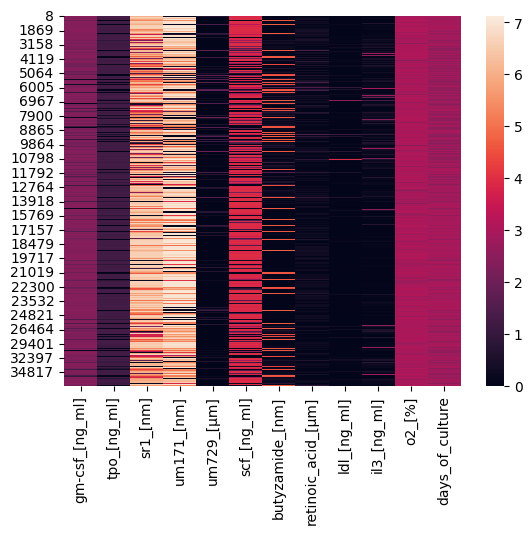

In [49]:
uq_incr_mask =plot_df["Delta Uncertainty"] < 0
print(f"Number of solutions for which the uncertainty increased after loop 1{uq_incr_mask.sum()}")
sns.heatmap(filtered_concs[uq_incr_mask])

Number of solutions for which the uncertainty decreased after loop 110121


<Axes: >

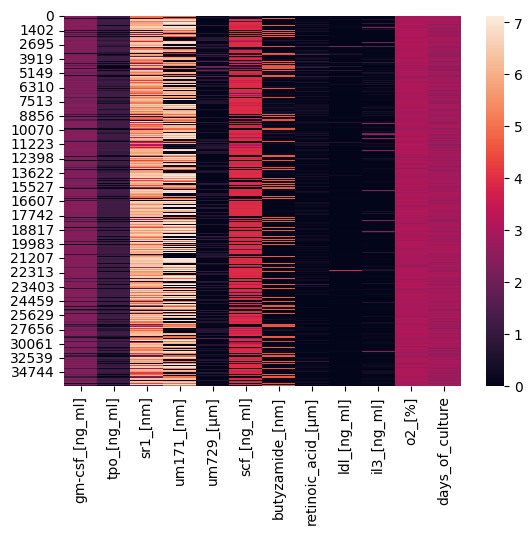

In [50]:
uq_decr_mask =plot_df["Delta Uncertainty"] > 0
print(f"Number of solutions for which the uncertainty decreased after loop 1{uq_decr_mask.sum()}")
sns.heatmap(filtered_concs[uq_decr_mask])